In [48]:
from Tools import *
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

# LaTex Formatierung in Plots
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "Computer Modern"
})

Standardabweichung_Periodendauer1:  0.08404663428534115
Mittelwert1:  3.6012000000000004


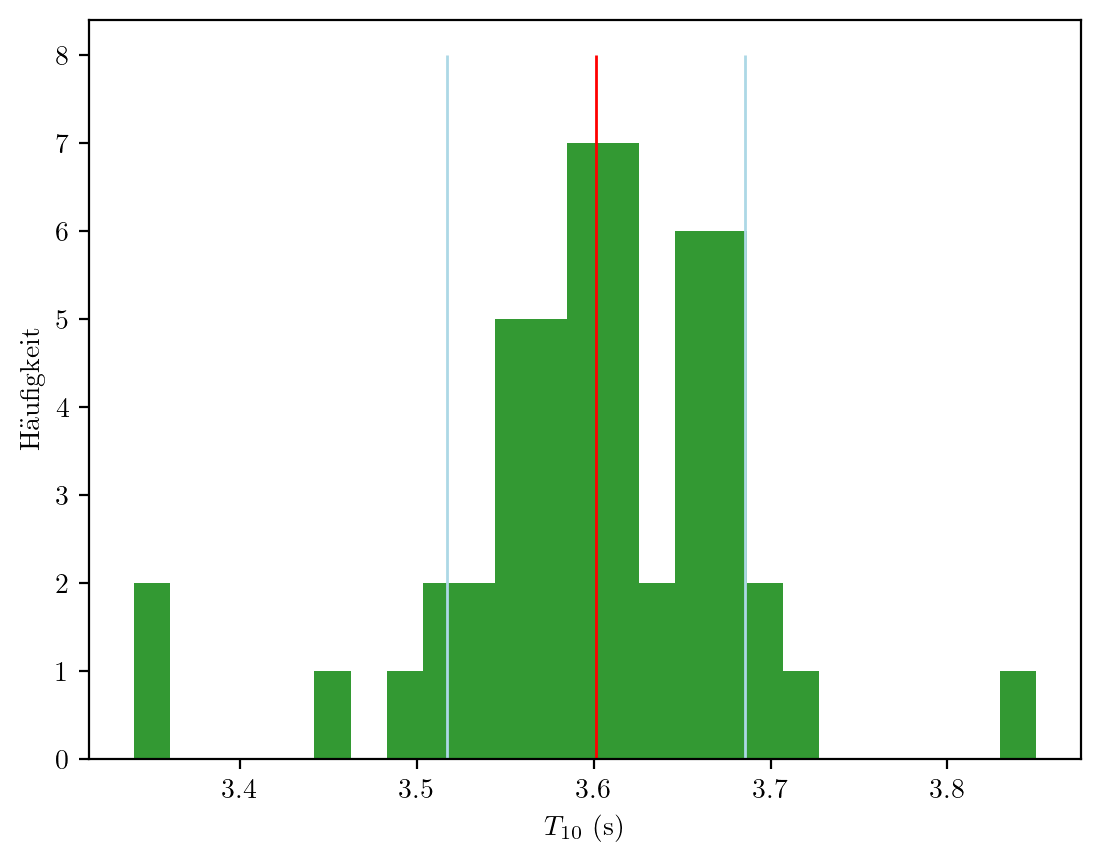

In [49]:
messdaten1 = pd.read_excel("V32.xlsx", sheet_name="MessungT1")
dauer = messdaten1["Zeit [s]"].to_numpy()
# dauer = dauer/10 # Messung für 10 Perioden

Standardabweichung_Periodendauer1 = (np.std(dauer, ddof=1)) # Stoppunsicherheit von 10 Perioden
Mittelwert1 = (np.mean(dauer))

print("Standardabweichung_Periodendauer1: ", Standardabweichung_Periodendauer1)
print("Mittelwert1: ", Mittelwert1)

fig, ax = plt.subplots(dpi=200)
ax.hist(dauer, bins=25, alpha=0.8, color='g', label="Messwerte")
ax.vlines(Mittelwert1, 0, 8, color='r', label="Mittelwert", linewidth=1)
ax.vlines([Mittelwert1+Standardabweichung_Periodendauer1, Mittelwert1-Standardabweichung_Periodendauer1],
          0, 8, color='lightblue', label="Mittelwert", linewidth=1)
# ax.set_title("Histogramm der Periodendauern für die Messung von Luft")
# ax.set_xticks()
ax.set_xlabel("$T_{10}$ (s)")
ax.set_ylabel("Häufigkeit")
plt.show()

In [50]:
messdaten2 = pd.read_excel("V32.xlsx", sheet_name="Messung2")
perioden = messdaten2["Perioden"].to_numpy()
dauer2 = messdaten2["Dauer (s)"].to_numpy()

# Periodendauer ohne vorzeitiges Runden berechnen
periodendauer2 = dauer2 / perioden
data2 = np.vstack([perioden, periodendauer2])
print(makeLaTexTable(data2, ("Perioden", "Periodendauer"), "Periodendauern über die Anzahl der gemessenen Perioden", tag="PeriodendauernLuft"))

\begin{table}[H]
\centering
\resizebox{\textwidth}{!}{
\begin{tabular}{l|llllllllll}
\textbf{Perioden}& 1.0	& 2.0	& 5.0	& 10.0	& 20.0	& 50.0	& 100.0	& 200.0	& 500.0	& 1000.0	\\ 
\textbf{Periodendauer}& 0.2	& 0.295	& 0.33599999999999997	& 0.358	& 0.379	& 0.3864	& 0.3895	& 0.39165	& 0.39274000000000003	& 0.3927	\\ 

\end{tabular}%
}
\caption{Periodendauern über die Anzahl der gemessenen Perioden}
\label{tab:PeriodendauernLuft}
\end{table}


In [51]:
# Kombination der Ergebnisse

# Individueller Fehler jedes Periodendauer-Messwerts:
# Die Unsicherheit der Gesamtzeit wird durch die Anzahl der Perioden geteilt.
fehler_periodendauer = Standardabweichung_Periodendauer1 / perioden

# Gewichtsfaktoren aus den individuellen Unsicherheiten
gewichte = 1 / fehler_periodendauer**2

# Gewichtetes arithmetisches Mittel
gewichtetes_mittel = np.sum(gewichte * periodendauer2) / np.sum(gewichte)
print("Gewichtetes Mittel: ", gewichtetes_mittel)

# Unsicherheit des gewichteten Mittels
fehler_gewichtetes_mittel = np.sqrt(1 / np.sum(gewichte))
print("Fehler des gewichteten Mittels: ", fehler_gewichtetes_mittel)
print("Individuelle Fehler: ", fehler_periodendauer)

Gewichtetes Mittel:  0.39263039223962615
Fehler des gewichteten Mittels:  7.362801957415947e-05
Individuelle Fehler:  [8.40466343e-02 4.20233171e-02 1.68093269e-02 8.40466343e-03
 4.20233171e-03 1.68093269e-03 8.40466343e-04 4.20233171e-04
 1.68093269e-04 8.40466343e-05]


Individuelle Fehler:  [8.40466343e-02 4.20233171e-02 1.68093269e-02 8.40466343e-03
 4.20233171e-03 1.68093269e-03 8.40466343e-04 4.20233171e-04
 1.68093269e-04 8.40466343e-05]


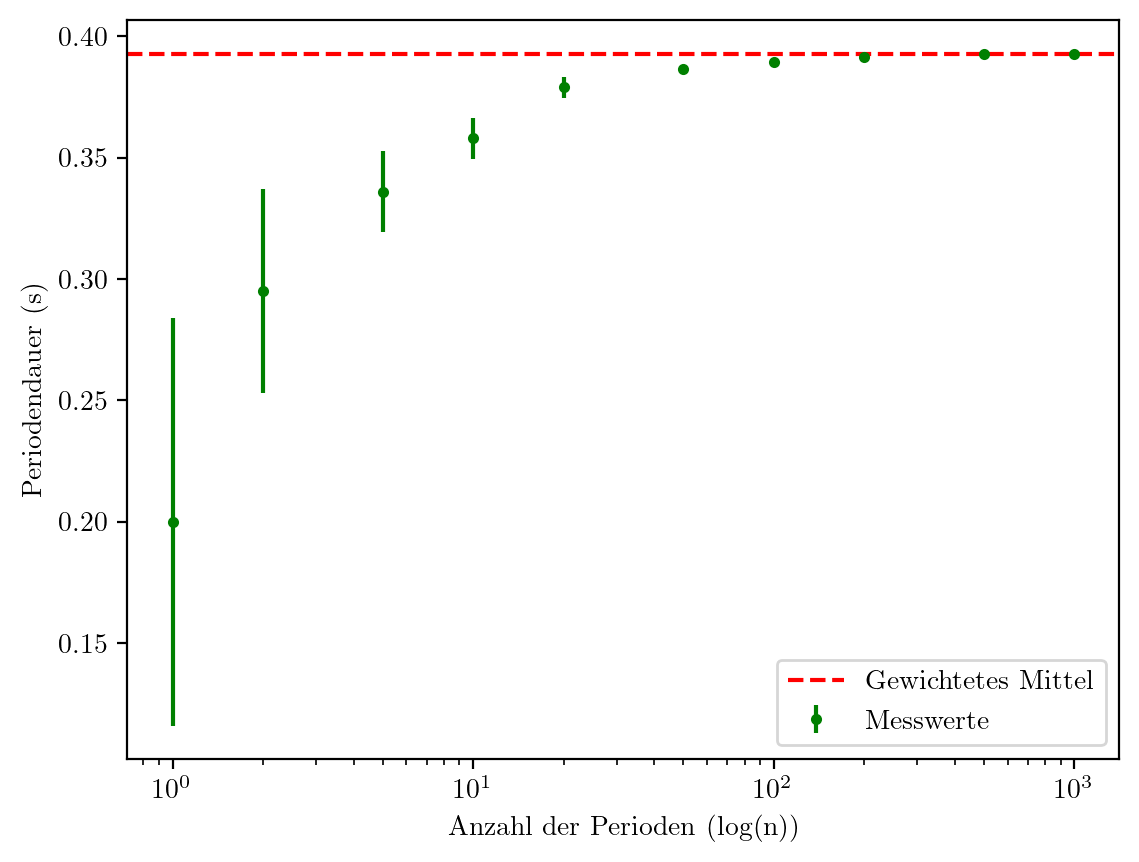

In [52]:
# Diagramm T (linear) gegen n (logarithmisch), Illustration von gewichtetes_Mittel

print("Individuelle Fehler: ", fehler_periodendauer)

fig, ax = plt.subplots(dpi=200)
ax.errorbar(perioden, periodendauer2, yerr=fehler_periodendauer, fmt='.', label='Messwerte', color='g')
ax.axhline(y=gewichtetes_mittel, color='r', linestyle='--', label='Gewichtetes Mittel')
ax.set_xscale('log')
ax.set_yscale('linear')
ax.set_xlabel('Anzahl der Perioden (log(n))')
ax.set_ylabel('Periodendauer (s)')
ax.legend(loc='lower right')
plt.show()

In [53]:
# Berechnung des Adiabatenexponenten
m = 5.67e-3
g = 9.808
V = 2220e-6
d = 13.8e-3
pL = 99050
# manuelle Berechnung
A = np.pi * (d/2)**2
p = pL + (4*m*g)/(np.pi*d**2)
kappa = (4 * np.pi**2 * m * V) / (A**2 * p * gewichtetes_mittel**2) 

# Gausfunktion zur Fehlerfortpflanzung
sm, sg, sV, sd, spL, sgewichtetes_mittel= sp.symbols('m g V d \\rho_L T')
# kappa_f = (4 * np.pi**2 * sm * sV) / ((np.pi * (sd/2)**2)**2 * (pL + (4*m*g)/(np.pi*d**2)) * gewichtetes_mittel**2)
kappa_f = ((64 * sm * sV)/(sd**4 * (spL + (4*sm*sg)/(np.pi*sd**2)) * sgewichtetes_mittel**2))

k = (gauss_error_values(
    kappa_f,
    [sm, sg, sV, sd, spL, sgewichtetes_mittel],
    [m, g, V, d, pL, gewichtetes_mittel],
    [0.006e-3, 0.001, 10e-6, 0.02e-3, 20, fehler_gewichtetes_mittel],
    returnLaTex=True
))

print(k)
kappa = k[0]
kappafehler = k[1]

print("Adiabatenexponent: ", np.round(kappa, 3))
print("Literaturwert: ", 1.40)

Term von m: 2,334438479e-06
Term von g: 3,053564514e-13
Term von V: 4,261813397e-05
Term von d: 7,032286243e-05
Term von \rho_L: 8,499572482e-08
Term von T: 2,954464534e-07

1. Wert:
1,45

2. Fehler:
0,01

3. LaTeX-Formel:
\begin{equation*}\Delta f = \sqrt{\left(\frac{\partial f}{\partial m}\,\Delta m\right)^2+\left(\frac{\partial f}{\partial g}\,\Delta g\right)^2+\left(\frac{\partial f}{\partial V}\,\Delta V\right)^2+\left(\frac{\partial f}{\partial d}\,\Delta d\right)^2+\left(\frac{\partial f}{\partial \rho_{L}}\,\Delta \rho_{L}\right)^2+\left(\frac{\partial f}{\partial T}\,\Delta T\right)^2}} = \sqrt{\left(\frac{64 V}{T^{2} d^{4} \left(\rho_{L} + \frac{1.27 g m}{d^{2}}\right)} - \frac{81.49 V g m}{T^{2} d^{6} \left(\rho_{L} + \frac{1.27 g m}{d^{2}}\right)^{2}}\,\Delta m\right)^2+\left(- \frac{81.49 V m^{2}}{T^{2} d^{6} \left(\rho_{L} + \frac{1.27 g m}{d^{2}}\right)^{2}}\,\Delta g\right)^2+\left(\frac{64 m}{T^{2} d^{4} \left(\rho_{L} + \frac{1.27 g m}{d^{2}}\right)}\,\Delta V\right)^

<>:9: SyntaxWarning: invalid escape sequence '\g'
<>:9: SyntaxWarning: invalid escape sequence '\g'
C:\Users\oskar\AppData\Local\Temp\ipykernel_6496\1837724612.py:9: SyntaxWarning: invalid escape sequence '\g'
  ax.set_ylabel('$\gamma_f$')


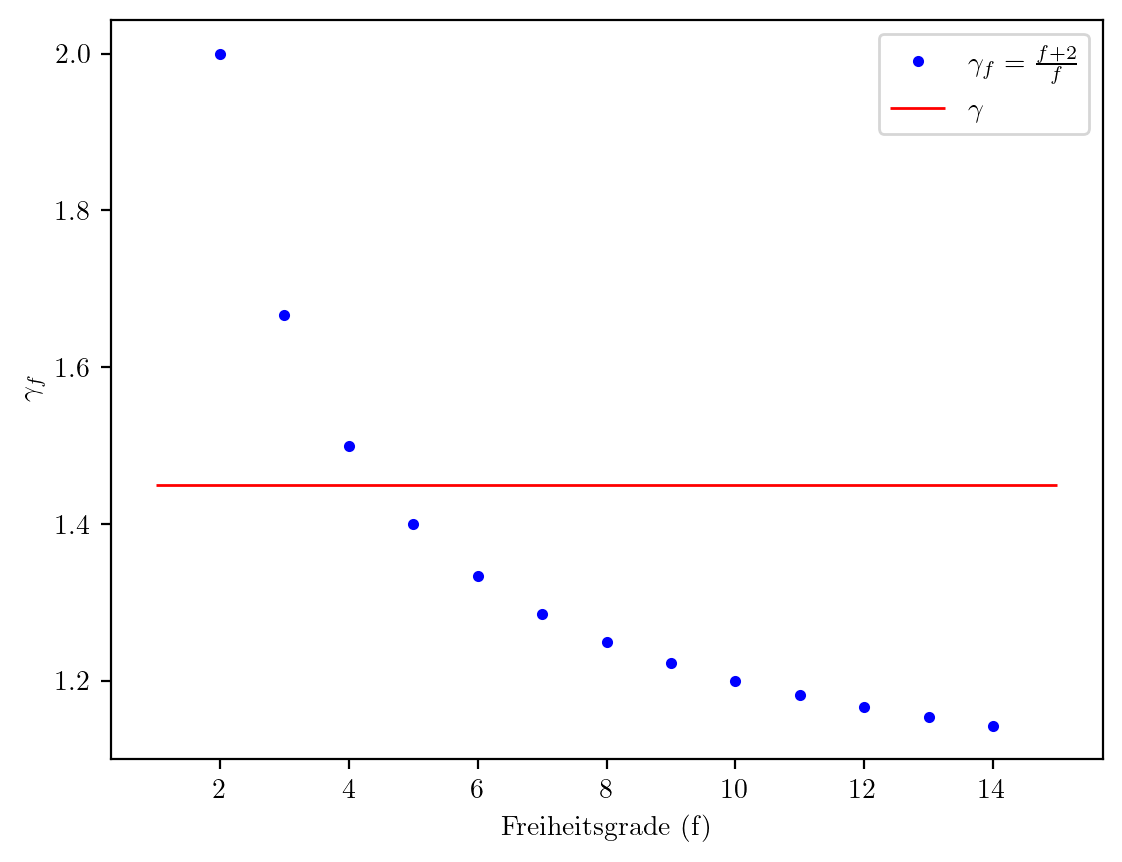

In [54]:
# gamma der Freiheitsgrade
f = np.arange(2, 15)
gammaf = (f+2)/f

fig, ax = plt.subplots(dpi=200)
ax.plot(f, gammaf, '.', label=r'$\gamma_f=\frac{f+2}{f}$', color='b', linewidth=1)
ax.hlines(y=kappa, xmin=1, xmax=15, color='r', linestyle='-', label=r'$\gamma$', linewidth=1)
ax.set_xlabel('Freiheitsgrade (f)')
ax.set_ylabel('$\gamma_f$')
ax.legend()
plt.show()

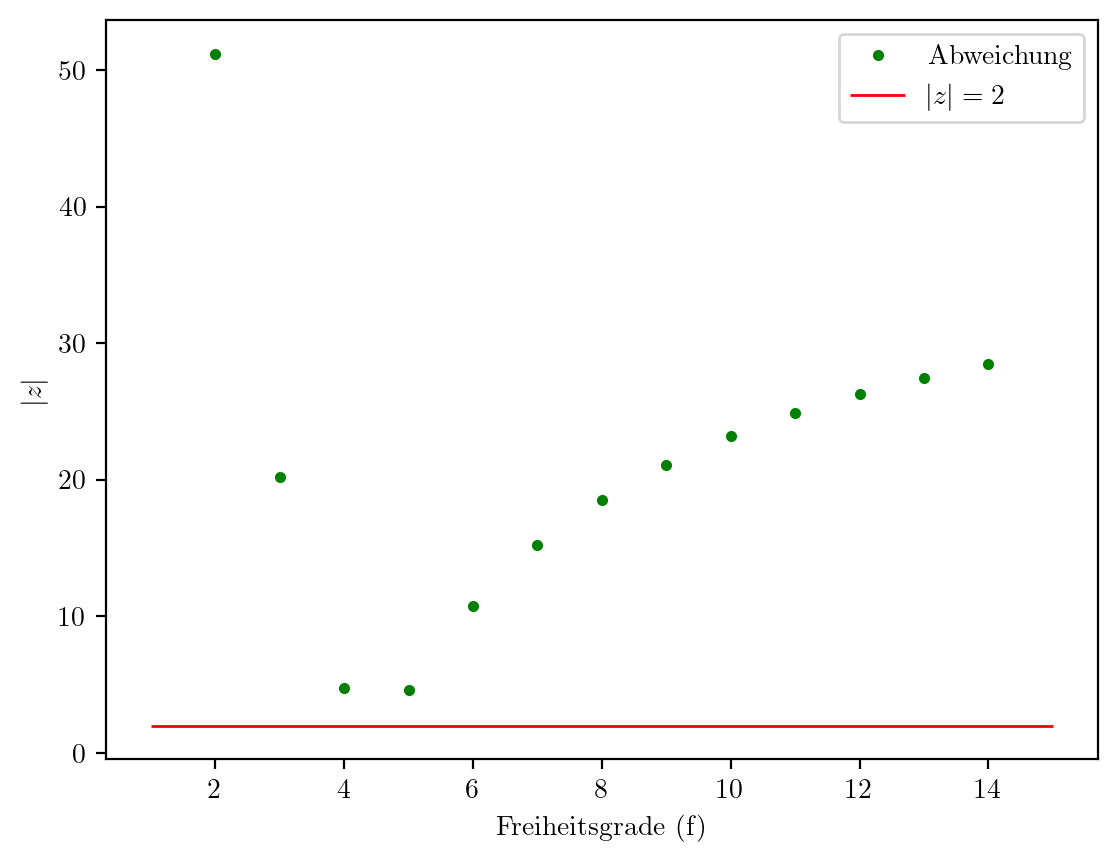

In [55]:
# Diagramm |z| mit z = 2
z = (abs(kappa - gammaf))/kappafehler

fig, ax = plt.subplots(dpi=200)
ax.plot(f, z, '.', label='Abweichung', color='g', linewidth=1)
ax.hlines(y=2, xmin=1, xmax=15, color='r', linestyle='-', label='$|z|=2$', linewidth=1)
ax.set_xlabel('Freiheitsgrade (f)')
ax.set_ylabel('$|z|$')
ax.legend()
plt.show()